<a href="https://colab.research.google.com/github/izhanys/PBA_Bima_5026231060/blob/main/Tugas/Week%202/Week_2_2_Preprocessing_Bima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google_play_scraper textblob seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download('stopwords', quiet=True)

True

In [3]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    print(f'Uploaded: {fn} ({len(uploaded[fn])} bytes)')
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print('Loaded into df')

Saving review_bima_75000.csv to review_bima_75000.csv
Uploaded: review_bima_75000.csv (45993747 bytes)
Loaded into df


In [4]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,64cf8bb2-43bd-430d-9cde-b23fba4a5d16,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Try gblok gajelas kontl,5,0,NaN,2026-03-10 04:20:37,NaN,NaN,NaN
1,b224d50f-2c03-422f-a632-be4eea88f29a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jangan mahal2 harganya,5,0,NaN,2026-03-10 03:45:42,NaN,NaN,NaN
2,435972c2-7a26-436d-ba68-89cba47a9c60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,5.12.0,2026-03-10 03:42:26,NaN,NaN,5.12.0
3,41d826a3-1411-4b29-ba43-e3ea2fbd01f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tri terbaik,4,0,5.13.0,2026-03-10 03:39:43,NaN,NaN,5.13.0
4,e3c550aa-841a-457a-a9cf-218e495ea6cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bgs,5,0,5.12.0,2026-03-10 03:28:51,NaN,NaN,5.12.0
...,...,...,...,...,...,...,...,...,...,...,...
74995,2732aa11-86e6-40bb-bad8-87075e9f5dc2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Mahal, dah itu aja.",1,0,NaN,2024-12-13 14:22:22,"Hai Kak, mohon maaf ya. Penyesuaian harga demi...",2024-12-14 10:57:30,NaN
74996,06f2a0b4-c1fb-45e4-836b-41459d660571,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,5.5.0,2024-12-13 14:22:10,"Hi Kak, Terima kasih atas apresiasi yang diber...",2024-12-13 21:15:50,5.5.0
74997,fa4789a4-21e4-40d7-85f1-f6921f9546bf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,4,0,5.2.0,2024-12-13 14:20:46,"Hi Kak Rudi, Terima kasih atas apresiasi yang ...",2024-12-13 21:16:17,5.2.0
74998,dc582f29-8c82-466b-8f41-830e8da46d3e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Beli kuota yang masuk pulsa, kan bodoh",1,0,5.5.0,2024-12-13 14:08:57,"Hai Kak Stefano, maaf ya. Untuk kendalanya kam...",2024-12-13 07:21:09,5.5.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              75000 non-null  object
 1   userName              75000 non-null  object
 2   userImage             75000 non-null  object
 3   content               75000 non-null  object
 4   score                 75000 non-null  int64 
 5   thumbsUpCount         75000 non-null  int64 
 6   reviewCreatedVersion  63766 non-null  object
 7   at                    75000 non-null  object
 8   replyContent          74888 non-null  object
 9   repliedAt             74888 non-null  object
 10  appVersion            63766 non-null  object
dtypes: int64(2), object(9)
memory usage: 6.3+ MB


In [6]:
indonesian_stopwords = set(stopwords.words('indonesian'))

text_column = 'content'
all_text = ' '.join(df[text_column].dropna().astype(str))
words = all_text.lower().split()
filtered_words = [w for w in words if w not in indonesian_stopwords]
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(50)

print('Top 50 words (before full preprocessing):')
common_df = pd.DataFrame(common_words, columns=['word', 'count'])
common_df

Top 50 words (before full preprocessing):


,word,count
0,paket,12143
1,nya,10218
2,kuota,9257
3,jaringan,8259
4,beli,7964
5,sinyal,7551
6,tri,7489
7,bagus,7420
8,ga,6356
9,mahal,5968


In [7]:
df.loc[:, ['content', 'score', 'thumbsUpCount',
           'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,Try gblok gajelas kontl,5,0,NaN,2026-03-10 04:20:37,NaN,NaN
1,jangan mahal2 harganya,5,0,NaN,2026-03-10 03:45:42,NaN,NaN
2,mantap,5,0,5.12.0,2026-03-10 03:42:26,NaN,NaN
3,tri terbaik,4,0,5.13.0,2026-03-10 03:39:43,NaN,NaN
4,sangat bgs,5,0,5.12.0,2026-03-10 03:28:51,NaN,NaN
...,...,...,...,...,...,...,...
74995,"Mahal, dah itu aja.",1,0,NaN,2024-12-13 14:22:22,"Hai Kak, mohon maaf ya. Penyesuaian harga demi...",2024-12-14 10:57:30
74996,good,5,0,5.5.0,2024-12-13 14:22:10,"Hi Kak, Terima kasih atas apresiasi yang diber...",2024-12-13 21:15:50
74997,good,4,0,5.2.0,2024-12-13 14:20:46,"Hi Kak Rudi, Terima kasih atas apresiasi yang ...",2024-12-13 21:16:17
74998,"Beli kuota yang masuk pulsa, kan bodoh",1,0,5.5.0,2024-12-13 14:08:57,"Hai Kak Stefano, maaf ya. Untuk kendalanya kam...",2024-12-13 07:21:09


Stopwords Removal(Indonesian)

In [8]:
indonesian_stopwords_list = stopwords.words('indonesian')
print(indonesian_stopwords_list[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [9]:
print(len(indonesian_stopwords_list))

758


In [10]:
indonesian_stopwords_list

['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

/tmp/ipykernel_15018/4241831913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cdf, x='word', y='count', palette='viridis')


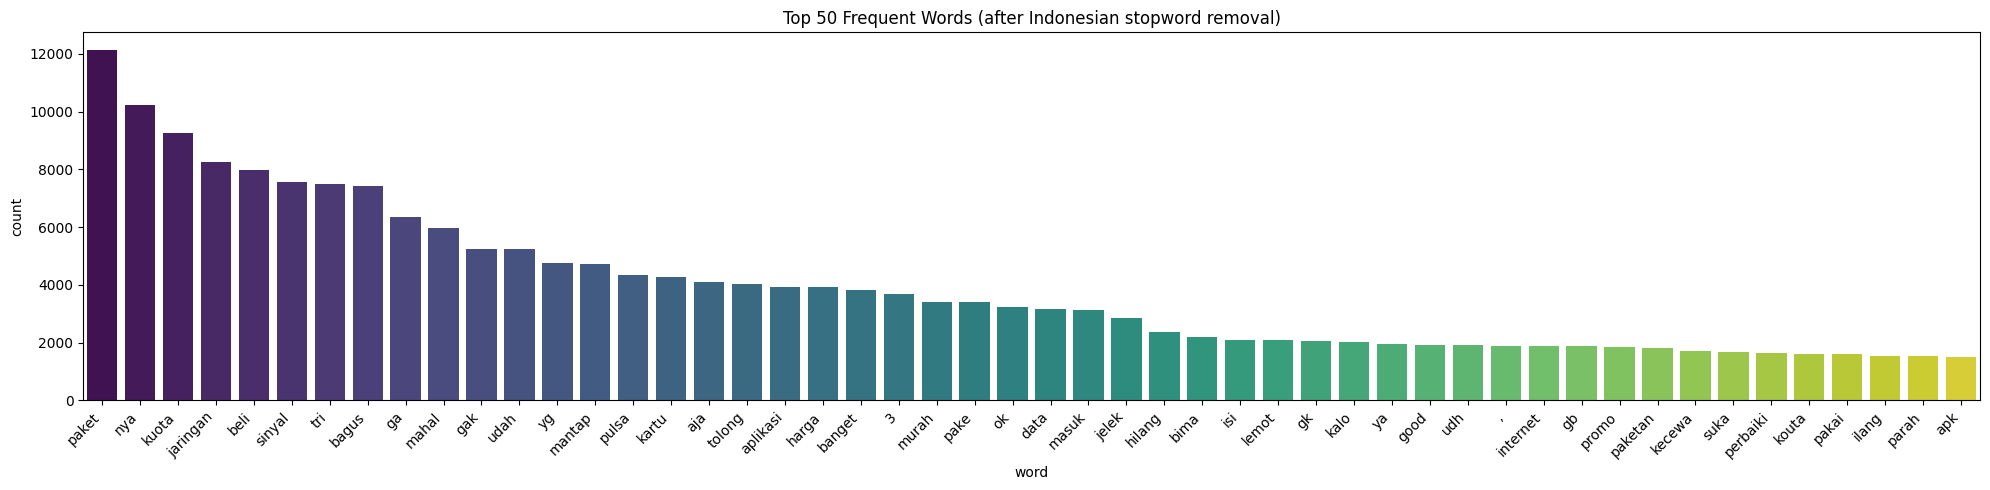

In [11]:
all_text = ' '.join(df['content'].dropna().astype(str))
words = all_text.lower().split()
filtered = [w for w in words if w not in indonesian_stopwords]
word_counts = Counter(filtered)
common_words = word_counts.most_common(50)

cdf = pd.DataFrame(common_words, columns=['word', 'count'])
plt.figure(figsize=(20, 5))
sns.barplot(data=cdf, x='word', y='count', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 50 Frequent Words (after Indonesian stopword removal)')
plt.tight_layout()
plt.show()

In [12]:
common_words

[('paket', 12143),
 ('nya', 10218),
 ('kuota', 9257),
 ('jaringan', 8259),
 ('beli', 7964),
 ('sinyal', 7551),
 ('tri', 7489),
 ('bagus', 7420),
 ('ga', 6356),
 ('mahal', 5968),
 ('gak', 5254),
 ('udah', 5231),
 ('yg', 4747),
 ('mantap', 4723),
 ('pulsa', 4344),
 ('kartu', 4263),
 ('aja', 4086),
 ('tolong', 4019),
 ('aplikasi', 3941),
 ('harga', 3911),
 ('banget', 3818),
 ('3', 3677),
 ('murah', 3405),
 ('pake', 3390),
 ('ok', 3238),
 ('data', 3181),
 ('masuk', 3144),
 ('jelek', 2869),
 ('hilang', 2375),
 ('bima', 2201),
 ('isi', 2103),
 ('lemot', 2078),
 ('gk', 2045),
 ('kalo', 2036),
 ('ya', 1940),
 ('good', 1934),
 ('udh', 1911),
 (',', 1885),
 ('internet', 1875),
 ('gb', 1872),
 ('promo', 1865),
 ('paketan', 1825),
 ('kecewa', 1699),
 ('suka', 1666),
 ('perbaiki', 1656),
 ('kouta', 1622),
 ('pakai', 1610),
 ('ilang', 1552),
 ('parah', 1540),
 ('apk', 1486)]